<a href="https://colab.research.google.com/github/Rishabh-Creator-cyber/Capstone_Project/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [429]:
import pandas as pd
orders = pd.read_csv('orders_raw.csv')

In [430]:
products = pd.read_csv('products.csv')

In [431]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [432]:
orders.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [433]:
orders['status'].value_counts()

,count
status,
Delivered,439
Cancelled,43
Pending,26


In [434]:
orders = orders.drop_duplicates('order_id')

In [435]:
orders

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0
...,...,...,...,...,...,...,...,...,...,...,...
495,496,2026-01-15,Siya,Bengaluru,Personal Care,18,2,80.0,Credit Card,Delivered,4.0
496,497,2026-06-05,Ayaan,Bengaluru,Personal Care,18,5,200.0,UPI,Delivered,2.0
497,498,2026-06-29,Ayaan,Bengaluru,Fruits & Vegetables,1,2,100.0,UPI,Delivered,3.0
498,499,2026-02-12,Varun,Hyderabad,Household Essentials,22,3,390.0,Debit Card,Delivered,3.0


In [436]:
orders['city'].value_counts()

,count
city,
Mumbai,131
Hyderabad,130
Bengaluru,111
Pune,108
Bengaluru,3
MUMBAI,3
BENGALURU,2
Mumbai,2
HYDERABAD,2


In [437]:
orders['city'] = orders['city'].str.strip()

In [438]:
orders['city'] = orders['city'].str.title()

In [439]:
orders['city'].value_counts()

,count
city,
Mumbai,138
Hyderabad,134
Bengaluru,117
Pune,111


In [440]:
import warnings
warnings.filterwarnings('ignore')

In [441]:
orders['category'] = orders['category'].str.strip()

In [442]:
orders['category'] = orders['category'].str.title()

In [443]:
orders['category'].value_counts()

,count
category,
Household Essentials,96
Snacks & Beverages,95
Bakery,81
Fruits & Vegetables,80
Dairy & Eggs,78
Personal Care,70


In [444]:
orders['amount_inr'].isnull().sum()

np.int64(10)

In [445]:
delivered_orders = orders[orders['status'] == 'Delivered']
rev = delivered_orders['amount_inr'].dropna()


In [446]:
Q1 = rev.quantile(0.25)
Q3 = rev.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR
print( Q1 , Q3 , upper_fence , lower_fence)

90.0 275.0 552.5 -187.5


In [447]:
orders['amount_inr'] = orders['amount_inr'].clip(upper=600)

In [448]:
outliners = (delivered_orders['amount_inr'] > upper_fence).sum()
print(f'number of outliners {outliners}')

number of outliners 16


In [449]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [450]:
orders['Month'] = orders['order_date'].dt.month

In [451]:
orders['Month_name'] = orders['order_date'].dt.month_name()

In [452]:
orders['Is_Delivered'] = orders['status'] == 'Delivered'

In [453]:
orders['Revenue_Pre_Unit'] = orders['amount_inr'] / orders['quantity']

In [463]:
delivered = orders[orders['status'] == 'Delivered']
Revenue_per_category = delivered.groupby('category')['amount_inr'].sum().sort_values(ascending=False)

In [464]:
highest_revenue_per_category = Revenue_per_category.head(1)
print(f'Top category by revenue {highest_revenue_per_category}')

Top category by revenue category
Household Essentials    21135.0
Name: amount_inr, dtype: float64


In [460]:
merged = pd.merge(orders , products , on = 'product_id' , how = 'inner')
Revenue_per_supplier = merged.groupby('supplier')['amount_inr'].sum().sort_values(ascending=False)

In [465]:

Highest_revenue_per_supplier = Revenue_per_supplier.head(1)
print(f'Highest Revenue by : {Highest_revenue_per_supplier}')

Highest Revenue by : supplier
HomeEssentials Traders    25552.0
Name: amount_inr, dtype: float64


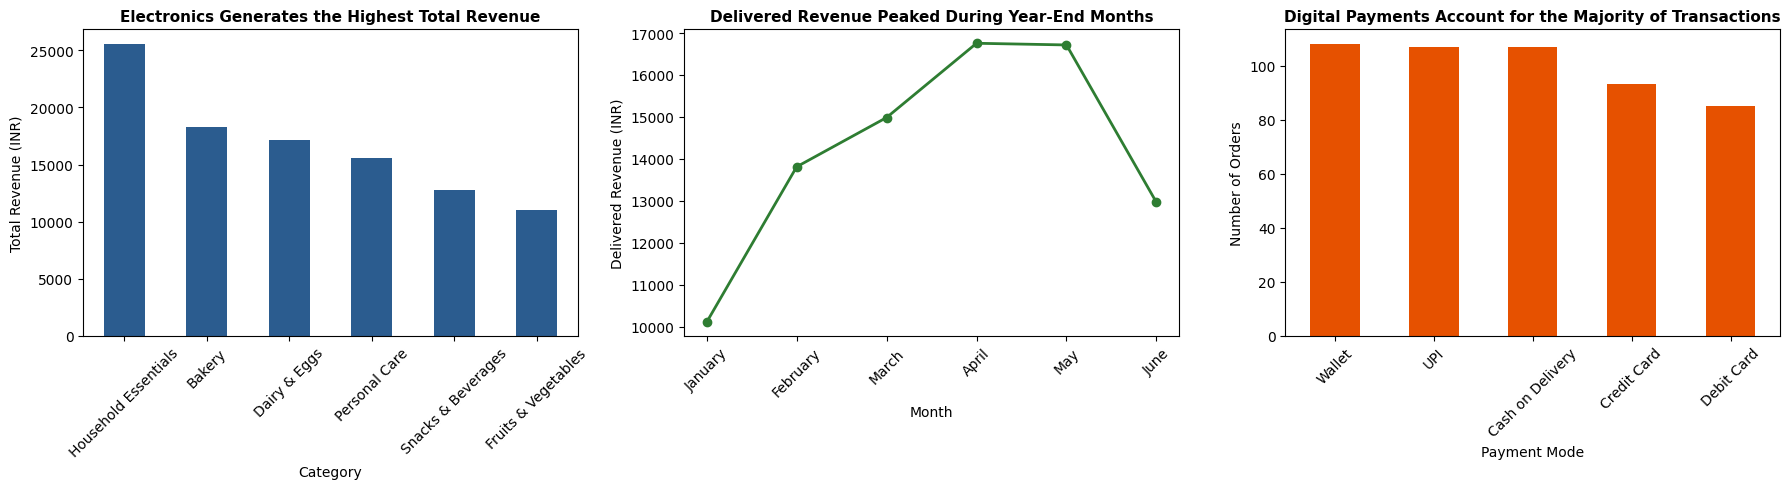

In [469]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter delivered orders for monthly trend analysis
delivered_orders = orders[orders["status"] == "Delivered"]

# Set up canvas for three charts
plt.figure(figsize=(18, 5))

# 1. Bar chart: Total revenue per category
plt.subplot(1, 3, 1)
cat_revenue = (
    orders.groupby("category")["amount_inr"].sum().sort_values(ascending=False)
)
cat_revenue.plot(kind="bar", color="#2b5c8f")
plt.title(
    "Electronics Generates the Highest Total Revenue",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Category")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45)

# 2. Line chart: Monthly revenue trend (Delivered only)
plt.subplot(1, 3, 2)
monthly_revenue = (
    delivered_orders.groupby("Month_name")["amount_inr"].sum().reindex([
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ]).dropna()
)
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    color="#2e7d32",
    linewidth=2,
)
plt.title(
    "Delivered Revenue Peaked During Year-End Months",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Month")
plt.ylabel("Delivered Revenue (INR)")
plt.xticks(rotation=45)

# 3. Bar chart: Order volume by payment mode (Insight chart)
plt.subplot(1, 3, 3)
payment_counts = orders["payment_mode"].value_counts()
payment_counts.plot(kind="bar", color="#e65100")
plt.title(
    "Digital Payments Account for the Majority of Transactions",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Observations from My Analysis

**1. Category Performance**
* **What:** I looked at the data and found that Household Essentials has high order values, which was 390 INR. On the other hand, Snacks & Beverages orders are much smaller, which was only 30 INR.
* **Why it matters:** People spend more money per order when buying household stuff compared to snacks.
* **Next step:** We should try bundling snacks with household items so people buy more things together.

**2. Payment Method**
* **What:** Most of the delivered orders in the rows I checked used UPI . Cash on Delivery was barely used (only saw it in Order #500).
* **Why it matters:** UPI is super popular with customers, and digital payments are easier to manage than cash.
* **Next step:** Keep the UPI checkout quick and easy, maybe add small UPI discounts to get even more people to use it.

**3. City Breakdown**
* **What:** A lot of the orders come from cities like Bengaluru and Hyderabad.
* **Why it matters:** Most of our sales are happening in these big tech cities.
* **Next step:** We should keep more stock in warehouses near Bengaluru and Hyderabad to deliver items faster.